# Initial Exploration of Incorporating Player-Level Data: World Cup 2022
Using the 2022 World Cup Players by League page on football reference (<https://fbref.com/en/comps/1/2022/leagues/2022-World-Cup-Players-By-League>), this notebook aims to explore what predictiveness can be added by incorporating roster data, beginning with players' professional league affiliation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Setup: Creating the Y matrix and importing team rankings
The below code is adapted from the `wc_2022_exploration` notebook. It creates the Y matrix we'll be using and imports FIFA ranking data that can be incorporated into X matrices. For now, I will NOT be standardizing any of the X data, but it may need to be standardized later.

In [16]:
# Compile the team-level 2022 results in a list, team_results_2022
# 2D list; each row is: team, games, goals_scored, goals_allowed, score_average
wc_2022 = pd.read_csv(r'Data Exploration\wc_2022.csv')
team_list = wc_2022['team1'].unique()
team_results_2022 = []
for team in team_list:
    games = 0
    goals_scored = 0
    goals_allowed = 0
    for i in range(wc_2022.shape[0]):
        if wc_2022.iloc[i, 0]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 5]
            goals_allowed += wc_2022.iloc[i, 6]
        elif wc_2022.iloc[i, 1]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 6]
            goals_allowed += wc_2022.iloc[i, 5]
    score_average = (goals_scored/games - goals_allowed/games)
    team_results_2022.append([team, games, goals_scored, goals_allowed, score_average])

# Generate the Y matrix:
score_average = []
for i in range(len(team_results_2022)):
    score_average.append(team_results_2022[i][4])
score_average=np.array(score_average)

# The following vector, games played per team, will be used in exploratory plots:
games_played = []
for i in range(len(team_results_2022)):
    games_played.append(team_results_2022[i][1])

# Import FIFA ranking data from the last pre-tournament rankings
fifa_rankings = pd.read_csv(r'Data Exploration\fifa_ranking-2024-06-20.csv')
rankings_2022 = fifa_rankings[fifa_rankings['rank_date']=='2022-10-06']
# Now-deleted exploration revealed that 30 out of 32 strings matched in these datasets
# This code fixes the two exceptions:
edited_teams = team_list
edited_teams[3] = 'USA'
edited_teams[25] = 'IR IRAN'

# Generate ordinal ranking_list:
ranking_list=[]
for team in edited_teams:
    for i in range(rankings_2022.shape[0]):
        if rankings_2022.iloc[i, 1].casefold() == team.casefold():
            ranking_list.append(rankings_2022.iloc[i, 0])

# Create an X matrix of the ordinal ranking data + an intercept term
ordinal_data_matrix = np.array(ranking_list)
ones = np.ones((len(ranking_list), 1))
ordinal_data_matrix = np.transpose(np.vstack((np.array(ranking_list), np.ones((len(ranking_list))))))

# Generate list based off of ranking points rather than the ordinal list
rpoints_list=[]
for team in edited_teams:
    for i in range(rankings_2022.shape[0]):
        if rankings_2022.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2022.iloc[i, 3])

# Create an X matrix of ranking points + an intercept term
rpoints_data_matrix = np.array(rpoints_list)
ones = np.ones((len(rpoints_list), 1))
rpoints_data_matrix = np.transpose(np.vstack((np.array(rpoints_list), np.ones((len(rpoints_list))))))


## Setup: Aggregation of # of players in top European leagues per country

The fbref 2022 World Cup Players by League play summarizes the league affiliations of players in a variety of ways, breaking down the total number of players from each league in the tournament--both individually for each nation and aggregated by league--as well as number of countries with a player from a particular league on their roster, total minutes played by players from each league, etc. The most represented leagues at the 2022 World Cup were the five major European professional leagues: the English Premier League, Spain's La Liga, the German Bundesliga, Italy's Serie A, and France's Ligue 1. After those leagues, the next most represented league was America's Major League Soccer, but its representation was much smaller both in terms of total number of players in the tournament, number of countries featuring players from the league, and total minutes played by players from the league. Therefore, let's begin by transcribing the number of players in each of these top leagues for each country to explore how this data can enrich our analysis.

This data has been transcribed by hand from fbref and may need to be proofread by a second set of eyes.

In [14]:
EPL = np.array([0, 25, 6, 6, 5, 7, 1, 5, 2, 4, 5, 7, 5, 3, 10, 12,
                9, 3, 0, 2, 2, 2, 1, 2, 3, 1, 0, 0, 0, 0, 5, 1])
La_Liga = np.array([0, 0, 3, 2, 10, 4, 1, 5, 4, 2, 18, 4, 1, 4, 2, 5,
                    0, 2, 0, 1, 1, 3, 0, 1, 1, 0, 1, 0, 0, 0, 2, 6])
Bundesliga = np.array([0, 1, 1, 2, 1, 6, 0, 6, 1, 20, 1, 3, 7, 0, 2, 0,
                        0, 2, 1, 2, 7, 5, 1, 2, 2, 1, 0, 0, 1, 0, 1, 1])
Serie_A = np.array([0, 0, 2, 2, 4, 2, 2, 3, 2, 0, 0, 2, 2, 3, 2, 3,
                    1, 4, 1, 9, 0, 4, 4, 1, 0, 0, 1, 0, 0, 0, 0, 11])
Ligue_1 = np.array([0, 0, 5, 1, 2, 1, 0, 6, 5, 0, 2, 3, 2, 0, 3, 2,
                    2, 0, 2, 2, 3, 1, 4, 0, 1, 0, 0, 0, 2, 1, 5, 0])
# Aggregate of total players in these 'big 5' leagues:
t5league = EPL + La_Liga + Bundesliga + Serie_A + Ligue_1

In [19]:
t5league

array([ 0, 26, 17, 13, 22, 20,  4, 25, 14, 26, 26, 19, 17, 10, 19, 22, 12,
       11,  4, 16, 13, 15, 10,  6,  7,  2,  2,  0,  3,  1, 13, 19])

# Expl. #1: Aggregate players in top leagues and scoring average

First we'll start by using `t5league`, an aggregation of the number of players each nation rostered from one of the top 5 European professional leagues, to create some of the same basic plots and correlations that we initially explored with FIFA rankings in other notebooks.

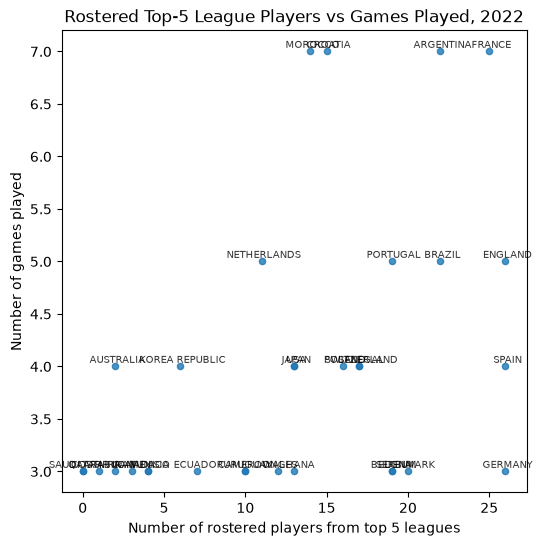

In [25]:
# Plotting t5league vs. games played
# Does having more players from these leagues tend to lead to longer tournament runs?
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(t5league, games_played, s=20, alpha = 0.8)
for i in range(len(edited_teams)):
    ax.annotate(edited_teams[i], xy=(t5league[i], games_played[i]), xytext=(1.5,2.6),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Number of rostered players from top 5 leagues')
ax.set_ylabel('Number of games played')
ax.set_title('Rostered Top-5 League Players vs Games Played, 2022')
plt.show()

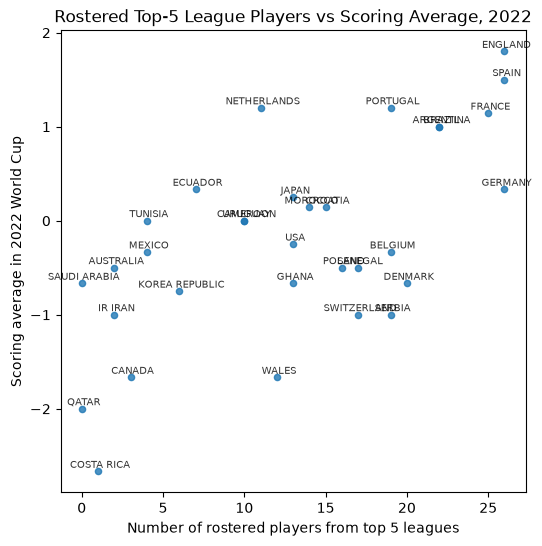

In [26]:
# Now plotting number of rostered players vs. scoring average
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(t5league, score_average, s=20, alpha = 0.8)
for i in range(len(edited_teams)):
    ax.annotate(edited_teams[i], xy=(t5league[i], score_average[i]), xytext=(1.5,2.6),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Number of rostered players from top 5 leagues')
ax.set_ylabel('Scoring average in 2022 World Cup')
ax.set_title('Rostered Top-5 League Players vs Scoring Average, 2022')
plt.show()

In [ ]:
# Running a regression on t5leagues vs. scoring average
# First, I'll create a data matrix with a ones column for my intercept term
t5league_data_matrix = np.transpose(np.vstack((t5league, np.ones((len(t5league))))))
# Now to run the regression:
t5league_coefs = np.linalg.lstsq(t5league_data_matrix, np.array(score_average))
t5league_coefs

(array([ 0.08122611, -1.24215741]),
 array([19.50760534]),
 np.int32(2),
 array([86.53891972,  3.0025613 ]))

In [44]:
print(f'For top 5 league composition vs. scoring average, the regression residual is {t5league_coefs[1]}')

For top 5 league composition vs. scoring average, the regression residual is [19.50760534]


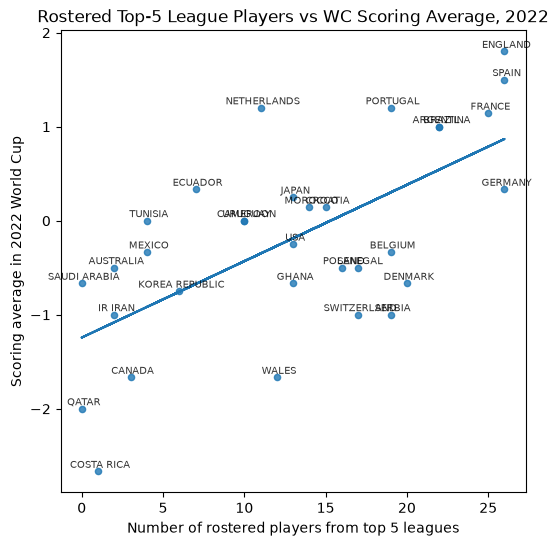

In [46]:
t5_slope, t5_intercept = t5league_coefs[0]
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(t5league, score_average, s=20, alpha = 0.8)
for i in range(len(edited_teams)):
    ax.annotate(edited_teams[i], xy=(t5league[i], score_average[i]), xytext=(1.5,2.6),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Number of rostered players from top 5 leagues')
ax.set_ylabel('Scoring average in 2022 World Cup')
ax.set_title('Rostered Top-5 League Players vs WC Scoring Average, 2022')
ax.plot(t5league, t5_slope*t5league + t5_intercept)
plt.show()